In [1]:

from urllib.parse import urlparse, unquote
import os

# Original file URI (file:///...)
PDF_URI = "file:///C:/Users/senth/OneDrive/Receipts/Adobe%20Scan%2027%20Dec%202025%20(6).pdf"
PDF_DIR = "C:\\Users\\senth\\OneDrive\\Receipts"

# Parse and convert to a Windows path
parsed = urlparse(PDF_URI)
path = unquote(parsed.path)
# On Windows, url path may start with a leading slash: '/C:/...'
if path.startswith('/') and os.name == 'nt':
    path = path.lstrip('/')

# Normalize to Windows-style path
PDF_PATH = os.path.normpath(path)

# If you want directory and filename separately, use os.path
PDF_DIR = os.path.dirname(PDF_PATH)
PDF_NAME = os.path.basename(PDF_PATH)
# Reconstruct (joined) path using os.path.join for consistency
PDF_TESTFILE = os.path.join(PDF_DIR, PDF_NAME)

print("PDF_PATH (Windows):", PDF_TESTFILE)

PDF_PATH (Windows): C:\Users\senth\OneDrive\Receipts\Adobe Scan 27 Dec 2025 (6).pdf


In [2]:
# Cell 1: Setup and Configuration
from langchain_ollama import ChatOllama

# Initialize the Local LLM via Ollama
# Ensure Ollama is running in the background!
llm = ChatOllama(
    model="qwen3-vl",  # Or your preferred local vision model
    temperature=0
)

print("Agent initialized and connected to local Ollama instance.")

c:\src\venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Agent initialized and connected to local Ollama instance.


In [3]:
# Demo: ping qwen3-vl using ChatOllama
from langchain_ollama import ChatOllama

try:
    demo = ChatOllama(model="qwen3-vl", validate_model_on_init=True, temperature=0)

    resp = demo.invoke("Please reply with just the single word: YES")
    text = getattr(resp, "content", None) or getattr(resp, "text", None) or str(resp)
    print("Ping response:", text)

    print("\nStreaming test:")
    for chunk in demo.stream("Say YES"):
        # chunk may be AIMessageChunk-like; print text field
        print(chunk.text, end="")

except Exception as e:
    print("ChatOllama demo failed:", e)


c:\src\venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Ping response: YES

Streaming test:
YES

In [3]:
# OCR a PDF with docTR (CPU-only; system has no CUDA)
# - Uses `PDF_TESTFILE` if defined; otherwise falls back to `PDF_PATH` (existing in this notebook)
# - Returns the raw docTR `result` and a simple plain-text extraction for quick inspection

from pathlib import Path
from doctr.io import DocumentFile
from doctr.models import ocr_predictor
import json


def ocr_pdf_doctr(pdf_path: str,
                  det_arch: str = "db_resnet50",
                  reco_arch: str = "crnn_vgg16_bn",
                  pretrained: bool = True,
                  assume_straight_pages: bool = True,
                 ) -> tuple:
    """Run OCR on `pdf_path` with docTR and return (result, plain_text).
    This is CPU-only: it forces/ensures inference runs on the CPU (no CUDA checks).
    Plain text is assembled by joining detected words by line and blocks by newline.
    """
    # Load the PDF as a docTR Document
    doc = DocumentFile.from_pdf(pdf_path)

    # Initialize predictor
    model = ocr_predictor(det_arch, reco_arch, pretrained=pretrained,
                          assume_straight_pages=assume_straight_pages)

    # Ensure CPU-only (move to CPU when supported, ignore if not)
    try:
        model.to("cpu")
    except Exception:
        pass

    # Run inference (docTR handles batching and multi-page PDF)
    result = model(doc)

    # Export as JSON-like nested dict and build plain text
    json_out = result.export()

    pages_text = []
    for page in json_out.get("pages", []):
        page_lines = []
        for block in page.get("blocks", []):
            for line in block.get("lines", []):
                words = [w.get("value", "") for w in line.get("words", [])]
                if words:
                    page_lines.append(" ".join(words))
        pages_text.append("\n".join(page_lines))

    full_text = "\n\n".join([f"--- Page {i+1} ---\n" + p for i, p in enumerate(pages_text)])
    # Return JSON-exported structure for easier downstream processing and the plain text
    return json_out, full_text


# Demo; pick file variable from notebook
pdf_file = globals().get("PDF_TESTFILE") or globals().get("PDF_PATH")
if not pdf_file:
    raise RuntimeError("No PDF file found. Define `PDF_TESTFILE` or set `PDF_PATH` first.")
res_json, plain = ocr_pdf_doctr(pdf_file)
res, plain = ocr_pdf_doctr(pdf_file)
# Print short preview (first 800 chars)
# Print short preview (first 800 chars) and page count
print('\n--- OCR PREVIEW ---')

# Print the JSON output (may be large)
print('\n--- JSON OUTPUT ---')
print(json.dumps(res_json, indent=2))

print('\n--- SUMMARY ---')
print(f"Pages: {len(res_json.get('pages', []))} | Total text length: {len(plain)} chars")



out_txt = Path(pdf_file).with_suffix(".doctr.json")    

with open(out_txt, "w", encoding="utf-8") as f:
    json.dump(res_json, f, ensure_ascii=False, indent=2)


c:\src\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- OCR PREVIEW ---

--- JSON OUTPUT ---
{
  "pages": [
    {
      "page_idx": 0,
      "dimensions": [
        1686,
        622
      ],
      "orientation": {
        "value": null,
        "confidence": null
      },
      "language": {
        "value": null,
        "confidence": null
      },
      "blocks": [
        {
          "geometry": [
            [
              0.010290017081993563,
              0.1064453125
            ],
            [
              0.9261800391881029,
              0.9208984375
            ]
          ],
          "objectness_score": 0.40560619024669425,
          "lines": [
            {
              "geometry": [
                [
                  0.5476474577974276,
                  0.1064453125
                ],
                [
                  0.5873536726286174,
                  0.115234375
                ]
              ],
              "objectness_score": 0.3277360796928406,
              "words": [
                {
              

In [ ]:
# New cell: send OCR JSON + page images to qwen3-vl via Ollama
from pathlib import Path
import json
import base64
from io import BytesIO
from PIL import Image

# Get PDF file from notebook variables
pdf_file = globals().get("PDF_TESTFILE") or globals().get("PDF_PATH")
if not pdf_file:
    raise RuntimeError("No PDF file found. Define `PDF_TESTFILE` or set `PDF_PATH` first.")

# Run OCR (uses existing ocr_pdf_doctr in this notebook)
res_json, plain = ocr_pdf_doctr(pdf_file)
print(f"OCR completed: {len(res_json.get('pages', []))} pages")

# Save outputs
out_txt = Path(pdf_file).with_suffix(".doctr.txt")
with open(out_txt, "w", encoding="utf-8") as f:
    f.write(plain)
print(f"Saved plain text -> {out_txt}")

out_json = Path(pdf_file).with_suffix(".doctr.json")
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(res_json, f, ensure_ascii=False, indent=2)
print(f"Saved JSON -> {out_json}")

# Convert PDF pages to images (try pdf2image then fallback to PyMuPDF)
images = []
try:
    from pdf2image import convert_from_path
    images = convert_from_path(pdf_file, dpi=200)
    print(f"Converted PDF to {len(images)} images with pdf2image")
except Exception as ex:
    import traceback
    print("pdf2image conversion failed:", ex)
    traceback.print_exc()
    

# Helper: image -> data URI
def img_to_datauri(img: Image.Image) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")

# Save images and create data URIs
data_uris = []
for idx, im in enumerate(images, start=1):
    out_img = Path(pdf_file).with_suffix(f".page-{idx}.png")
    im.save(out_img)
    print(f"Saved page image -> {out_img}")
    data_uris.append(img_to_datauri(im))


OCR completed: 1 pages
Saved plain text -> C:\Users\senth\OneDrive\Receipts\Adobe Scan 27 Dec 2025 (6).doctr.txt
Saved JSON -> C:\Users\senth\OneDrive\Receipts\Adobe Scan 27 Dec 2025 (6).doctr.json
Converted PDF to 1 images with pdf2image
Saved page image -> C:\Users\senth\OneDrive\Receipts\Adobe Scan 27 Dec 2025 (6).page-1.png


Initialized ChatOllama with model qwen3-vl

--- PROMPT PREVIEW ---
You are an assistant. Below is OCR JSON produced by docTR and the corresponding page images. Treat any word/token that has a 'confidence' value >= 0.9 as HIGH_CONF and accept it as reliable. For words with lower confidence, mark them with [LOW_CONF] in your output. Return: 1) A consolidated plain-text extraction (one paragraph per page), 2) For each page, list low-confidence phrases with their text and page/line location. Do NOT hallucinate text not present in the JSON or images.


DOCTR_JSON:
{"pages": [{"page_idx": 0, "dimensions": [1686, 622], "orientation": {"value": null, "confidence": null}, "language": {"value": null, "confidence": null}, "blocks": [{"geometry": [[0.010290017081993563, 0.1064453125], [0.9261800391881029, 0.9208984375]], "objectness_score": 0.40560619024669425, "lines": [{"geometry": [[0.5476474577974276, 0.1064453125], [0.5873536726286174, 0.115234375]], "objectness_score": 0.3277360796928406, "w
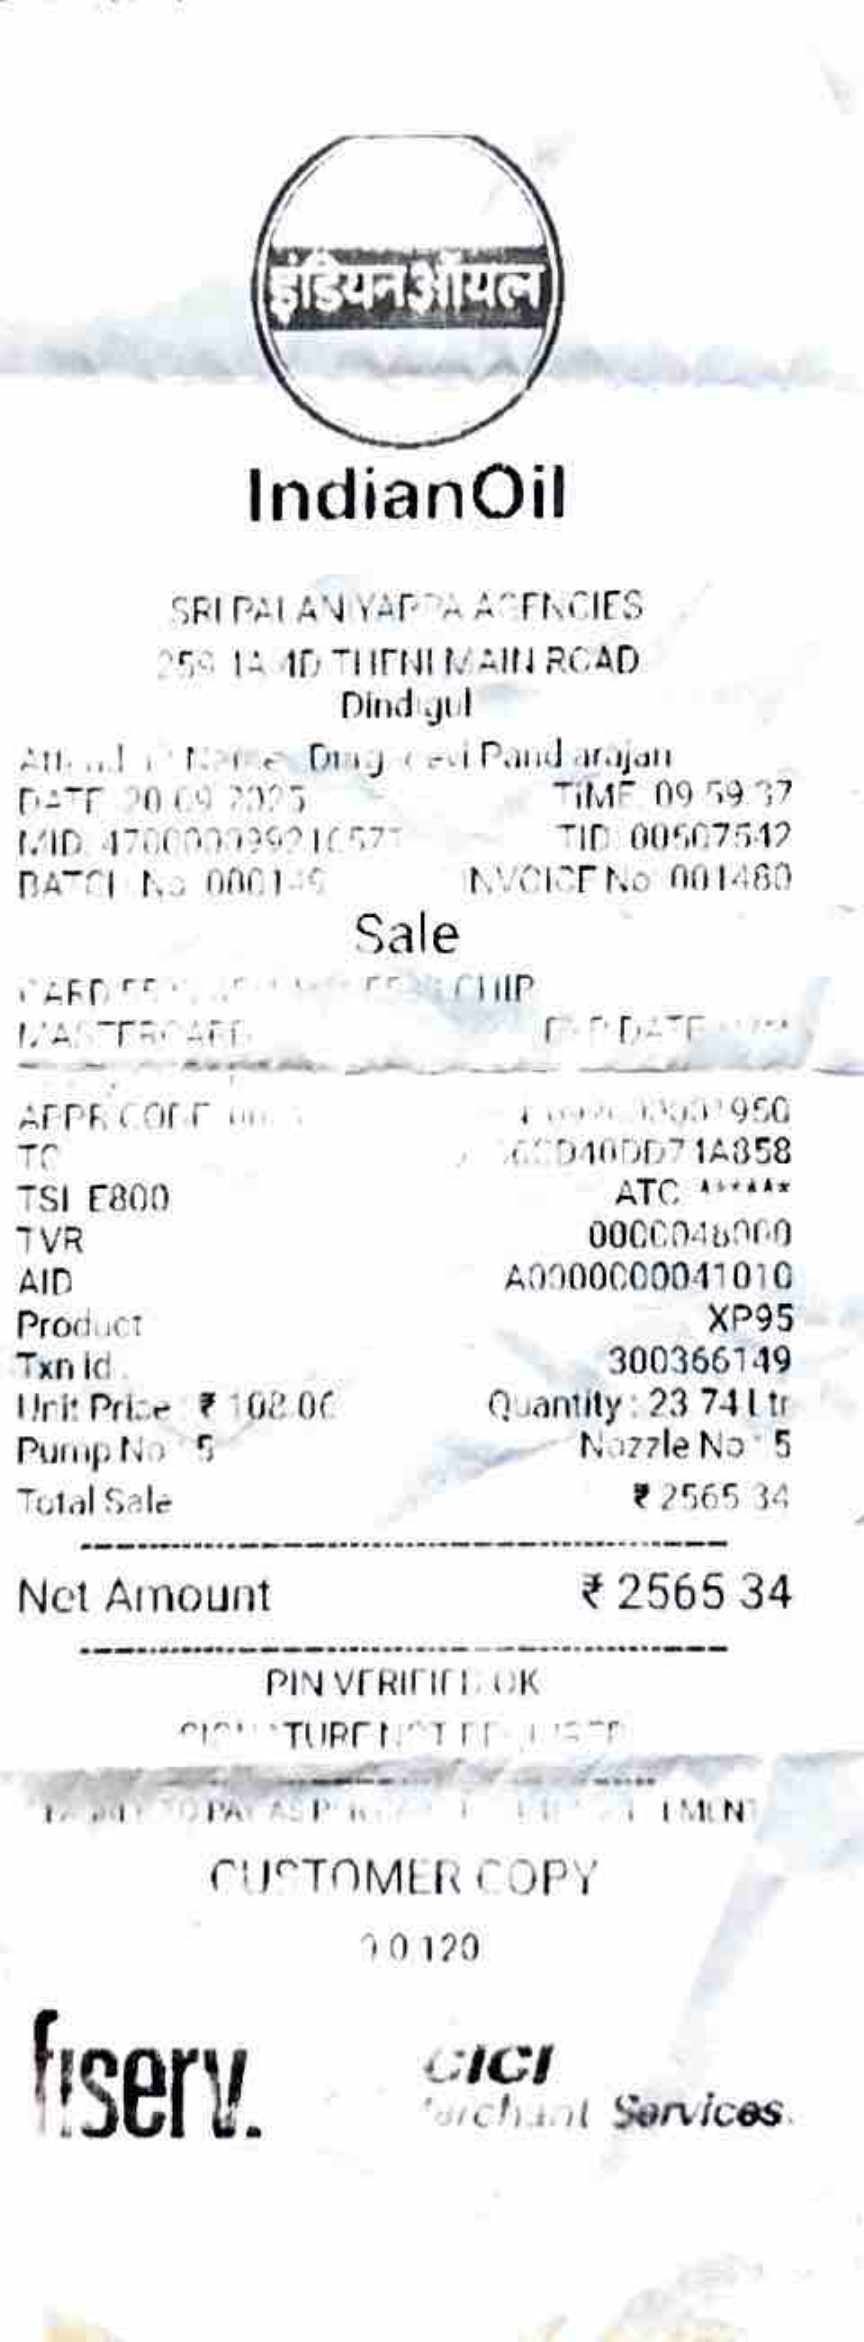

In [ ]:

# Initialize Ollama qwen3-vl
from langchain_ollama import ChatOllama
try:
    ollama = ChatOllama(model="qwen3-vl", validate_model_on_init=True, temperature=0)
    print("Initialized ChatOllama with model qwen3-vl")
except Exception as e:
    print("Failed to initialize Ollama model:", e)
    ollama = None

# Instruction: treat confidence >= 0.9 as HIGH_CONF
instruction = (
    "You are an assistant. Below is OCR JSON produced by docTR and the corresponding page images. "
    "Treat any word/token that has a 'confidence' value >= 0.9 as HIGH_CONF and accept it as reliable. "
    "For words with lower confidence, mark them with [LOW_CONF] in your output. "
    "Return: 1) A consolidated plain-text extraction (one paragraph per page), 2) For each page, list low-confidence phrases with their text and page/line location. "
    "Do NOT hallucinate text not present in the JSON or images."
)

# Build prompt (include JSON and embedded images)
prompt_parts = [instruction, "\n\nDOCTR_JSON:", json.dumps(res_json, ensure_ascii=False)]
for i, uri in enumerate(data_uris, start=1):
    prompt_parts.append(f"\n\n--- PAGE {i} IMAGE ---\n![page{i}]({uri})")

prompt = "\n".join(prompt_parts)
print ('\n--- PROMPT PREVIEW ---')
print(prompt)
# Send prompt to model and print response
if ollama is not None:
    try:
        resp = ollama.invoke(prompt)
        text = getattr(resp, "content", None) or getattr(resp, "text", None) or str(resp)
        print('\n--- MODEL RESPONSE ---')
        print(text)
    except Exception as e:
        print("Error invoking model:", e)
else:
    print("Model not available; skipping inference.")

In [ ]:
import traceback
def check(name, fn):
    try:
        fn()
        print(name, "OK")
    except Exception as e:
        print(name, "ERROR:", e)
        traceback.print_exc()

check("pdf2image", lambda: __import__("pdf2image"))
check("PyMuPDF (fitz)", lambda: __import__("fitz"))
check("pdfminer.six", lambda: __import__("pdfminer"))

pdf2image OK
PyMuPDF (fitz) ERROR: No module named 'frontend'
pdfminer.six ERROR: No module named 'pdfminer'


Traceback (most recent call last):
  File "C:\Users\senth\AppData\Local\Temp\ipykernel_20756\3450754183.py", line 4, in check
    fn()
    ~~^^
  File "C:\Users\senth\AppData\Local\Temp\ipykernel_20756\3450754183.py", line 11, in <lambda>
    check("PyMuPDF (fitz)", lambda: __import__("fitz"))
                                    ~~~~~~~~~~^^^^^^^^
  File "c:\src\venv\Lib\site-packages\fitz\__init__.py", line 1, in <module>
    from frontend import *
ModuleNotFoundError: No module named 'frontend'
Traceback (most recent call last):
  File "C:\Users\senth\AppData\Local\Temp\ipykernel_20756\3450754183.py", line 4, in check
    fn()
    ~~^^
  File "C:\Users\senth\AppData\Local\Temp\ipykernel_20756\3450754183.py", line 12, in <lambda>
    check("pdfminer.six", lambda: __import__("pdfminer"))
                                  ~~~~~~~~~~^^^^^^^^^^^^
ModuleNotFoundError: No module named 'pdfminer'
